# Evolutionary Algorithms for the Nurse Rostering Problem

This notebook designs, implements, and tests two evolutionary algorithms for
the Nurse Rostering Problem (NRP). Both algorithms use exactly the same
representation, initialization, fitness function, selection, crossover,
mutation, elitism, population size, and evaluation budget. They differ only in
their constraint-handling technique:

1. **Penalty EA:** infeasible rosters remain in the population and receive a
   large penalty.
2. **Repair EA:** offspring are repaired before evaluation and the same
   penalized fitness function is then applied.

The experiment uses the official **GPost** benchmark.

### Sources

- [Scheduling Benchmarks: GPost instance and verified solutions](https://www.schedulingbenchmarks.org/nrp/)
- [Published GPost solution with objective value 5](https://www.schedulingbenchmarks.org/nrp/data/solutions/html/GPost.Solution.5.html)
- Burke, E. K. and Curtois, T. (2014). *New approaches to nurse rostering
  benchmark instances*. European Journal of Operational Research, 237(1),
  71–81.
- [Aickelin, U. (2010). Nurse Rostering with Genetic Algorithms](https://arxiv.org/abs/1004.2870)
- Eiben, A. E. and Smith, J. E. (2015). *Introduction to Evolutionary
  Computing*, 2nd ed., Chapter 13: Constraint Handling.


## 1. Problem definition

The Nurse Rostering Problem assigns employees to shifts over a planning
horizon. In GPost, the roster has 8 employees and 28 days. Each cell is:

| Value | Meaning |
|---:|---|
| 0 | Off |
| 1 | Day shift (`D`) |
| 2 | Night shift (`N`) |

A roster is therefore:

$$X \in \{0,1,2\}^{8 \times 28}.$$

Every day requires exactly three day-shift employees and one night-shift
employee. The objective is to satisfy all hard constraints and minimize the
weighted soft-constraint penalty.


## 2. What is the difference between hard and soft constraints?

**Hard constraints define feasibility.** A roster that violates one is not an
acceptable schedule. In this benchmark model, hard constraints include:

- exactly 3 day shifts and 1 night shift on every day;
- at most one shift per employee per day (guaranteed by the representation);
- no employee may work more than two consecutive weekends.

**Soft constraints define quality.** They may be violated, but each violation
adds its published weight to the objective. GPost soft constraints include:

- maximum total shifts and maximum night shifts;
- requested shifts on the first two days;
- weekly workload ranges;
- complete weekends;
- undesirable work/off and night-shift patterns.

Thus, hard constraints answer “is the roster usable?” while soft constraints
answer “how good is the usable roster?”


## 3. How to penalize infeasibility and measure fitness?

The benchmark is a minimization problem. Let:

- $H(X)$ be the number of hard-constraint violation units;
- $S(X)$ be the official weighted soft penalty.

Both algorithms use the same cost:

$$
f(X)=W_H H(X)+S(X), \qquad W_H=1{,}000{,}000.
$$

Lower is better. The large hard weight makes any infeasible roster worse than
a feasible roster encountered by the search. Results report all three values
separately: penalized fitness, hard violations, and soft penalty. For a
feasible solution, $H(X)=0$ and fitness equals the benchmark objective.


## 4. How to represent solutions?

The representation is a direct $8\times28$ integer matrix. Rows are employees
`A`–`H`, columns are days 0–27, and every gene belongs to `{Off, D, N}`.

This representation automatically enforces “at most one shift per employee per
day.” It is also easy to decode into a human-readable roster. Crossover is
applied to the flattened matrix and mutation randomly resets one cell.


## 5. Constraint-handling approaches

### Penalty EA

No repair is applied. Crossover and mutation may produce infeasible rosters,
which are evaluated using $1{,}000{,}000H(X)+S(X)$.

### Repair EA

After crossover and mutation, repair:

1. restores exact daily coverage;
2. attempts shift-preserving swaps to break runs of three worked weekends.

The repaired roster is evaluated with exactly the same fitness function.
Therefore, the repair operation is the only difference between the two EAs.


## 6. Pseudocode

```text
Input: GPost instance, method, population size, maximum evaluations

Create random population with benchmark dimensions
If method is repair:
    repair every individual
Evaluate every individual with the same penalized fitness

while evaluations < maximum evaluations:
    copy the elite
    repeatedly:
        select two parents by binary tournament
        apply one-point crossover
        apply random-reset mutation
        if method is repair:
            repair both children
        add children to the new population
    evaluate the new population

return the best roster found
```


## 7. Operators, parameters, and justification

| Component | Choice |
|---|---|
| Representation | Employee-by-day integer matrix |
| Parent selection | Binary tournament |
| Crossover | One-point crossover on flattened roster |
| Mutation | Random reset with probability $1/(8\cdot28)$ |
| Survivor selection | Generational replacement with elitism |
| Constraint handling | Penalty or repair |

| Parameter | Value |
|---|---:|
| Population size | 80 |
| Maximum evaluations | 4,000 |
| Crossover probability | 0.9 |
| Tournament size | 2 |
| Independent runs per method | 10 |

The matrix mirrors the real schedule. Tournament selection works directly with
minimization and needs no scaling. One-point crossover and random reset are
simple operators that remain identical in both experiments. Elitism prevents
loss of the best roster. Ten runs are used because EAs are stochastic.


In [1]:
import time
import urllib.request
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SHIFT_OFF, SHIFT_DAY, SHIFT_NIGHT = 0, 1, 2
SHIFTS = np.array([SHIFT_OFF, SHIFT_DAY, SHIFT_NIGHT])
EMPLOYEE_IDS = list("ABCDEFGH")
N_EMPLOYEES, N_DAYS = 8, 28
FULL_TIME = np.array([True, True, True, True, False, False, False, False])

POPULATION_SIZE = 80
MAX_EVALUATIONS = 4000
CROSSOVER_PROBABILITY = 0.9
TOURNAMENT_SIZE = 2
N_RUNS = 10
HARD_WEIGHT = 1_000_000


## 8. Load the official benchmark and reference solution

The `.ros` and `.roster` files are bundled beside this notebook. If they are
missing, the notebook downloads them from the benchmark website.


In [2]:
DATA_DIR = Path("gpost")
DATA_DIR.mkdir(exist_ok=True)

FILES = {
    "GPost.ros": "https://www.schedulingbenchmarks.org/nrp/data/GPost.ros",
    "GPost.Solution.5.roster": (
        "https://www.schedulingbenchmarks.org/nrp/data/solutions/xml/"
        "GPost.Solution.5.roster"
    ),
}

for filename, url in FILES.items():
    path = DATA_DIR / filename
    if not path.exists():
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(url, path)


def parse_reference_roster(path):
    root = ET.parse(path).getroot()
    roster = np.zeros((N_EMPLOYEES, N_DAYS), dtype=int)
    for employee in root.findall("Employee"):
        nurse = EMPLOYEE_IDS.index(employee.attrib["ID"])
        for assignment in employee.findall("Assign"):
            day = int(assignment.findtext("Day"))
            shift = assignment.findtext("Shift")
            roster[nurse, day] = SHIFT_DAY if shift == "D" else SHIFT_NIGHT
    return roster, int(root.findtext("Penalty"))


reference_roster, published_optimum = parse_reference_roster(
    DATA_DIR / "GPost.Solution.5.roster"
)

benchmark_summary = pd.DataFrame([{
    "Instance": "GPost",
    "Employees": N_EMPLOYEES,
    "Days": N_DAYS,
    "Day demand": 3,
    "Night demand": 1,
    "Published optimum": published_optimum,
}])
benchmark_summary


,Instance,Employees,Days,Day demand,Night demand,Published optimum
0,GPost,8,28,3,1,5


## 9. Hard-constraint measurement

Coverage violations are measured as absolute staffing deviations. Consecutive
weekend violations count every three-week window in which an employee works
all three weekends. The matrix representation already prevents multiple shifts
for one employee on the same day.


In [3]:
WEEKEND_STARTS = [5, 12, 19, 26]  # Saturdays; every instance starts Monday.


def coverage_violation(roster):
    violation = 0
    for day in range(N_DAYS):
        violation += abs(int(np.sum(roster[:, day] == SHIFT_DAY)) - 3)
        violation += abs(int(np.sum(roster[:, day] == SHIFT_NIGHT)) - 1)
    return violation


def consecutive_weekend_violation(roster):
    violation = 0
    for row in roster:
        worked = [
            bool(np.any(row[saturday:min(saturday + 2, N_DAYS)] != SHIFT_OFF))
            for saturday in WEEKEND_STARTS
        ]
        violation += sum(all(worked[start:start + 3]) for start in range(2))
    return int(violation)


def hard_violations(roster):
    return coverage_violation(roster) + consecutive_weekend_violation(roster)


## 10. Official GPost soft-penalty function

The evaluator implements the weighted GPost rules from `GPost.ros`: contract
limits, weekly quadratic penalties, requests, complete weekends, work/off
patterns, and night patterns.


In [4]:
SHIFT_ON_REQUESTS = {
    (0, 0): SHIFT_DAY, (0, 1): SHIFT_DAY,
    (2, 0): SHIFT_DAY, (2, 1): SHIFT_DAY,
    (3, 0): SHIFT_NIGHT, (3, 1): SHIFT_NIGHT,
    (4, 0): SHIFT_DAY, (4, 1): SHIFT_DAY,
}


def boolean_blocks(values, target):
    blocks = []
    start = None
    for index, value in enumerate(values):
        if bool(value) == target and start is None:
            start = index
        if (bool(value) != target or index == len(values) - 1) and start is not None:
            end = index if bool(value) != target else index + 1
            blocks.append((start, end, end - start))
            start = None
    return blocks


def soft_penalty(roster):
    total = sum(
        1000 for position, requested_shift in SHIFT_ON_REQUESTS.items()
        if roster[position] != requested_shift
    )

    for nurse, row in enumerate(roster):
        work = row != SHIFT_OFF
        night = row == SHIFT_NIGHT
        full_time = FULL_TIME[nurse]

        total += 1000 * max(0, int(work.sum()) - (18 if full_time else 10))
        total += 1000 * max(0, int(night.sum()) - 4)

        # Single isolated day off: start-of-horizon or bounded by work.
        for start, end, length in boolean_blocks(work, False):
            if length == 1 and (start == 0 or (start > 0 and end < N_DAYS)):
                total += 10

        # Seven consecutive working days.
        total += 1000 * sum(np.all(work[start:start + 7]) for start in range(22))

        # Complete weekends.
        for saturday in WEEKEND_STARTS:
            if saturday + 1 < N_DAYS and work[saturday] != work[saturday + 1]:
                total += 100

        # Night and rest patterns.
        for friday in [4, 11, 18, 25]:
            if friday + 2 < N_DAYS:
                total += 1000 * int(
                    night[friday] and not work[friday + 1] and not work[friday + 2]
                )
        total += 1000 * sum(
            night[d] and not work[d + 1] and work[d + 2]
            for d in range(N_DAYS - 2)
        )
        total += 1000 * sum(
            night[d] and row[d + 1] == SHIFT_DAY
            for d in range(N_DAYS - 1)
        )
        total += 1000 * int(night[0] and not night[1])
        total += 1000 * sum(
            not night[d - 1] and night[d] and not night[d + 1]
            for d in range(1, N_DAYS - 1)
        )
        total += 1000 * sum(
            np.all(night[d:d + 4]) for d in range(N_DAYS - 3)
        )

        # Exact work-block patterns that end before the horizon.
        for start, end, length in boolean_blocks(work, True):
            if end < N_DAYS:
                if full_time and length in (1, 2, 3):
                    total += {1: 100, 2: 4, 3: 1}[length]
                if not full_time and length in (1, 4, 5, 6):
                    total += {1: 100, 4: 1, 5: 4, 6: 9}[length]

        # Weekly quadratic target ranges.
        minimum, maximum = (4, 5) if full_time else (2, 3)
        for week_start in [0, 7, 14, 21]:
            count = int(work[week_start:week_start + 7].sum())
            total += max(0, minimum - count) ** 2
            total += max(0, count - maximum) ** 2

    return int(total)


def fitness(roster):
    return HARD_WEIGHT * hard_violations(roster) + soft_penalty(roster)


## 11. Validate the evaluator

Before running either EA, the published roster is evaluated locally. It must
have zero hard violations and reproduce the published soft penalty of 5.


In [5]:
reference_check = pd.DataFrame([{
    "Published penalty": published_optimum,
    "Computed hard violations": hard_violations(reference_roster),
    "Computed soft penalty": soft_penalty(reference_roster),
    "Computed fitness": fitness(reference_roster),
}])

assert hard_violations(reference_roster) == 0
assert soft_penalty(reference_roster) == published_optimum
reference_check


,Published penalty,Computed hard violations,Computed soft penalty,Computed fitness
0,5,0,5,5


## 12. Shared initialization and evolutionary operators

Initialization begins with exact coverage but does not guarantee the
consecutive-weekend hard constraint. The same initializer is used for both
methods.


In [6]:
def random_roster(rng):
    roster = np.zeros((N_EMPLOYEES, N_DAYS), dtype=int)
    for day in range(N_DAYS):
        day_nurses = rng.choice(N_EMPLOYEES, size=3, replace=False)
        remaining = np.setdiff1d(np.arange(N_EMPLOYEES), day_nurses)
        night_nurse = rng.choice(remaining)
        roster[day_nurses, day] = SHIFT_DAY
        roster[night_nurse, day] = SHIFT_NIGHT
    return roster


def tournament_selection(population, costs, rng):
    candidates = rng.choice(len(population), TOURNAMENT_SIZE, replace=False)
    return population[candidates[np.argmin(costs[candidates])]].copy()


def one_point_crossover(parent1, parent2, rng):
    if rng.random() >= CROSSOVER_PROBABILITY:
        return parent1.copy(), parent2.copy()
    flat1, flat2 = parent1.ravel(), parent2.ravel()
    point = rng.integers(1, flat1.size)
    child1 = np.concatenate([flat1[:point], flat2[point:]]).reshape(parent1.shape)
    child2 = np.concatenate([flat2[:point], flat1[point:]]).reshape(parent1.shape)
    return child1, child2


def mutate(roster, rng):
    child = roster.copy()
    probability = 1 / child.size
    mask = rng.random(child.shape) < probability
    child[mask] = rng.choice(SHIFTS, size=int(mask.sum()))
    return child


## 13. Repair operator

The repair operator is used only by the Repair EA. Coverage is restored first.
Then shift-preserving weekend swaps are attempted, followed by another coverage
pass. Repair is heuristic: the common fitness function still measures any
hard violation that remains.


In [7]:
def repair_coverage(roster, rng):
    repaired = roster.copy()
    for day in range(N_DAYS):
        for shift, required in [(SHIFT_DAY, 3), (SHIFT_NIGHT, 1)]:
            assigned = np.where(repaired[:, day] == shift)[0]
            while len(assigned) > required:
                nurse = rng.choice(assigned)
                repaired[nurse, day] = SHIFT_OFF
                assigned = np.where(repaired[:, day] == shift)[0]
            while len(assigned) < required:
                candidates = np.where(repaired[:, day] == SHIFT_OFF)[0]
                if len(candidates) == 0:
                    # Free someone from the other shift if a malformed column is full.
                    other = SHIFT_NIGHT if shift == SHIFT_DAY else SHIFT_DAY
                    candidates = np.where(repaired[:, day] == other)[0]
                nurse = rng.choice(candidates)
                repaired[nurse, day] = shift
                assigned = np.where(repaired[:, day] == shift)[0]
    return repaired


def creates_three_weekends(roster, nurse):
    row = roster[nurse]
    worked = [
        bool(np.any(row[s:min(s + 2, N_DAYS)] != SHIFT_OFF))
        for s in WEEKEND_STARTS
    ]
    return any(all(worked[start:start + 3]) for start in range(2))


def repair_weekends(roster, rng):
    repaired = roster.copy()
    for nurse in range(N_EMPLOYEES):
        attempts = 0
        while creates_three_weekends(repaired, nurse) and attempts < 8:
            attempts += 1
            worked_weekends = [
                s for s in WEEKEND_STARTS
                if np.any(repaired[nurse, s:min(s + 2, N_DAYS)] != SHIFT_OFF)
            ]
            saturday = rng.choice(worked_weekends)
            changed = False
            for day in range(saturday, min(saturday + 2, N_DAYS)):
                shift = repaired[nurse, day]
                if shift == SHIFT_OFF:
                    continue
                candidates = np.where(repaired[:, day] == SHIFT_OFF)[0]
                rng.shuffle(candidates)
                for replacement in candidates:
                    trial = repaired.copy()
                    trial[nurse, day] = SHIFT_OFF
                    trial[replacement, day] = shift
                    if not creates_three_weekends(trial, replacement):
                        repaired = trial
                        changed = True
                        break
            if not changed:
                break
    return repaired


def repair_roster(roster, rng):
    repaired = repair_coverage(roster, rng)
    repaired = repair_weekends(repaired, rng)
    return repair_coverage(repaired, rng)


## 14. Evolutionary algorithm

The `method` switch controls only whether repair is called. All other code and
all random operators are shared.


In [8]:
def run_ea(method, seed):
    if method not in {"penalty", "repair"}:
        raise ValueError("method must be 'penalty' or 'repair'")

    rng = np.random.default_rng(seed)
    start_time = time.perf_counter()

    population = [random_roster(rng) for _ in range(POPULATION_SIZE)]
    if method == "repair":
        population = [repair_roster(ind, rng) for ind in population]

    costs = np.array([fitness(ind) for ind in population], dtype=float)
    evaluations = POPULATION_SIZE
    history_best = [float(costs.min())]
    history_average = [float(costs.mean())]

    best = population[int(np.argmin(costs))].copy()
    best_cost = float(costs.min())

    while evaluations < MAX_EVALUATIONS:
        elite = population[int(np.argmin(costs))].copy()
        new_population = [elite]

        while len(new_population) < POPULATION_SIZE:
            parent1 = tournament_selection(population, costs, rng)
            parent2 = tournament_selection(population, costs, rng)
            child1, child2 = one_point_crossover(parent1, parent2, rng)
            child1, child2 = mutate(child1, rng), mutate(child2, rng)

            if method == "repair":
                child1 = repair_roster(child1, rng)
                child2 = repair_roster(child2, rng)

            new_population.append(child1)
            if len(new_population) < POPULATION_SIZE:
                new_population.append(child2)

        population = new_population
        costs = np.array([fitness(ind) for ind in population], dtype=float)
        evaluations += POPULATION_SIZE

        generation_best = float(costs.min())
        if generation_best < best_cost:
            best_cost = generation_best
            best = population[int(np.argmin(costs))].copy()

        history_best.append(best_cost)
        history_average.append(float(costs.mean()))

    return {
        "method": method,
        "best_roster": best,
        "best_fitness": best_cost,
        "hard_violations": hard_violations(best),
        "soft_penalty": soft_penalty(best),
        "time_seconds": time.perf_counter() - start_time,
        "history_best": history_best,
        "history_average": history_average,
        "evaluations": evaluations,
    }


## 15. Experiment

Each method is run 10 times with the same seed sequence and exactly 4,000
fitness evaluations per run.


In [9]:
all_results = []
histories = {"penalty": [], "repair": []}
best_run = {}

for method in ["penalty", "repair"]:
    for run in range(N_RUNS):
        result = run_ea(method, seed=1000 + run)
        histories[method].append(result)
        all_results.append({
            "Method": method,
            "Run": run + 1,
            "Best fitness": result["best_fitness"],
            "Hard violations": result["hard_violations"],
            "Soft penalty": result["soft_penalty"],
            "Feasible": result["hard_violations"] == 0,
            "Time (s)": result["time_seconds"],
            "Evaluations": result["evaluations"],
        })
        if method not in best_run or result["best_fitness"] < best_run[method]["best_fitness"]:
            best_run[method] = result

results_df = pd.DataFrame(all_results)
results_df


,Method,Run,Best fitness,Hard violations,Soft penalty,Feasible,Time (s),Evaluations
0,penalty,1,2064433.0,2,64433,False,6.214815,4000
1,penalty,2,3070341.0,3,70341,False,6.144129,4000
2,penalty,3,2063156.0,2,63156,False,6.087074,4000
3,penalty,4,1067779.0,1,67779,False,6.102552,4000
4,penalty,5,2057077.0,2,57077,False,6.174629,4000
5,penalty,6,3061823.0,3,61823,False,6.132673,4000
6,penalty,7,2077160.0,2,77160,False,6.199885,4000
7,penalty,8,1077732.0,1,77732,False,6.067238,4000
8,penalty,9,2057422.0,2,57422,False,6.167258,4000
9,penalty,10,3055479.0,3,55479,False,6.197643,4000


## 16. Results

The table compares solution quality, feasibility, and computational time.
`Feasibility rate` is the percentage of runs whose best roster has zero hard
violations.


In [10]:
summary_df = (
    results_df.groupby("Method")
    .agg(
        best_fitness=("Best fitness", "min"),
        average_best_fitness=("Best fitness", "mean"),
        average_hard_violations=("Hard violations", "mean"),
        average_soft_penalty=("Soft penalty", "mean"),
        feasibility_rate_percent=("Feasible", lambda x: 100 * x.mean()),
        average_time_seconds=("Time (s)", "mean"),
        evaluations=("Evaluations", "first"),
    )
    .reset_index()
)
summary_df.round(3)


,Method,best_fitness,average_best_fitness,average_hard_violations,average_soft_penalty,feasibility_rate_percent,average_time_seconds,evaluations
0,penalty,1067779.0,2165240.2,2.1,65240.2,0.0,6.149,4000
1,repair,20459.0,27085.4,0.0,27085.4,100.0,8.258,4000


## 17. Convergence and method comparison

The convergence curves average the 10 runs. Lower fitness is better. The
separate hard-violation and time plots reveal whether improved feasibility
comes with additional repair cost.


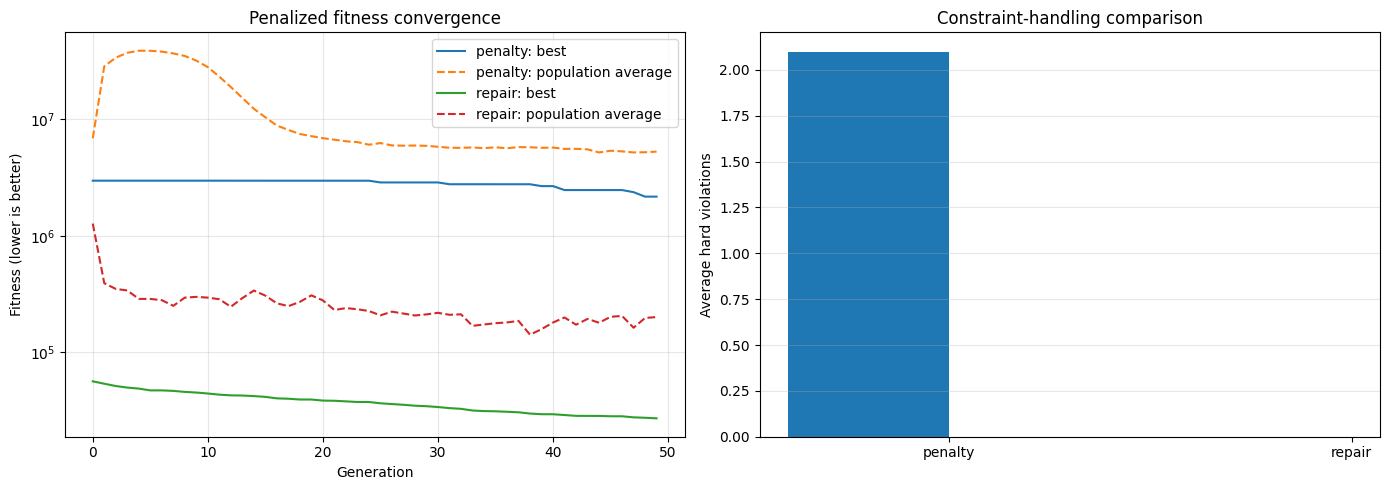

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for method in ["penalty", "repair"]:
    best_curves = np.array([result["history_best"] for result in histories[method]])
    average_curves = np.array([result["history_average"] for result in histories[method]])
    axes[0].plot(best_curves.mean(axis=0), label=f"{method}: best")
    axes[0].plot(
        average_curves.mean(axis=0),
        linestyle="--",
        label=f"{method}: population average",
    )

axes[0].set_title("Penalized fitness convergence")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Fitness (lower is better)")
axes[0].set_yscale("symlog")
axes[0].grid(alpha=0.3)
axes[0].legend()

x = np.arange(2)
axes[1].bar(
    x - 0.2,
    summary_df["average_hard_violations"],
    width=0.4,
    label="Average hard violations",
)
axes[1].set_xticks(x, summary_df["Method"])
axes[1].set_title("Constraint-handling comparison")
axes[1].set_ylabel("Average hard violations")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


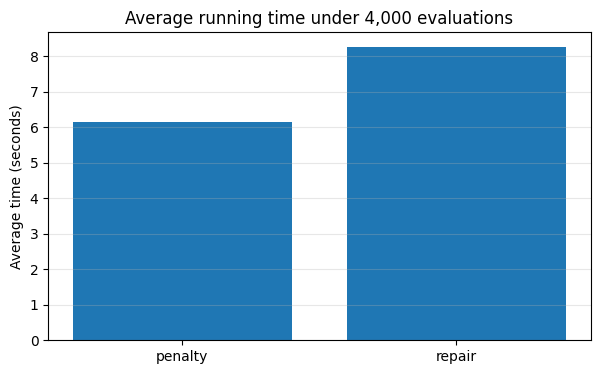

In [12]:
plt.figure(figsize=(7, 4))
plt.bar(summary_df["Method"], summary_df["average_time_seconds"])
plt.ylabel("Average time (seconds)")
plt.title("Average running time under 4,000 evaluations")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 18. Inspect the best rosters




In [13]:
def roster_to_dataframe(roster):
    mapping = {SHIFT_OFF: "O", SHIFT_DAY: "D", SHIFT_NIGHT: "N"}
    readable = np.vectorize(mapping.get)(roster)
    return pd.DataFrame(
        readable,
        index=EMPLOYEE_IDS,
        columns=[f"Day {day}" for day in range(N_DAYS)],
    )


comparison = pd.DataFrame([
    {
        "Roster": "Published optimum",
        "Fitness": fitness(reference_roster),
        "Hard violations": hard_violations(reference_roster),
        "Soft penalty": soft_penalty(reference_roster),
    },
    *[
        {
            "Roster": f"Best {method} EA",
            "Fitness": result["best_fitness"],
            "Hard violations": result["hard_violations"],
            "Soft penalty": result["soft_penalty"],
        }
        for method, result in best_run.items()
    ],
])
comparison


,Roster,Fitness,Hard violations,Soft penalty
0,Published optimum,5.0,0,5
1,Best penalty EA,1067779.0,1,67779
2,Best repair EA,20459.0,0,20459


In [14]:
roster_to_dataframe(best_run["repair"]["best_roster"])

,Day 0,Day 1,Day 2,Day 3,Day 4,Day 5,Day 6,Day 7,Day 8,Day 9,...,Day 18,Day 19,Day 20,Day 21,Day 22,Day 23,Day 24,Day 25,Day 26,Day 27
A,O,D,D,D,D,O,O,O,O,D,...,N,N,D,O,O,D,D,N,N,D
B,N,N,N,O,O,D,D,D,D,O,...,D,D,D,D,D,O,O,O,D,D
C,D,D,D,N,O,O,D,N,N,N,...,D,O,O,D,N,N,N,D,O,O
D,D,D,O,O,D,O,O,D,D,O,...,O,D,N,N,D,O,D,D,O,O
E,O,O,D,D,O,D,D,D,O,O,...,O,O,O,O,O,O,O,O,O,N
F,D,O,O,O,N,N,N,O,O,D,...,D,D,D,O,O,D,O,O,D,D
G,O,O,O,O,O,O,O,O,O,O,...,O,O,O,D,O,D,D,D,D,O
H,O,O,O,D,D,D,O,O,D,D,...,O,O,O,O,D,O,O,O,O,O


## 19. Interpretation and answers

The two algorithms differ only in constraint handling. The Penalty EA permits
infeasible candidates and relies on selection pressure created by the large
hard penalty. The Repair EA modifies offspring before the same fitness
evaluation. Its additional domain knowledge should improve feasibility, but
repair also increases running time.

### What is the difference between hard and soft constraints?

Hard constraints determine whether a roster is feasible. Soft constraints
measure preferences and quality; violations are permitted but penalized.

### How is infeasibility penalized and fitness measured?

Hard violation units are multiplied by 1,000,000 and added to the official
weighted GPost soft penalty. The EA minimizes this total. Hard violations and
soft penalty are also reported separately to avoid hiding infeasibility inside
one number.

### How are solutions represented?

Each solution is an $8\times28$ integer matrix. Rows are employees, columns are
days, and each cell is Off, Day, or Night. This representation guarantees at
most one shift per employee per day.

The reference-solution assertion demonstrates that the implemented evaluator
reproduces the benchmark value 5 with zero hard violations. 
